# DL CSI Fingerprint Localization

## Package Requirements

Run this notebook with the repository virtual environment:

```bash
source .techtile_env/bin/activate
python -m pip install torch
```

Required Python packages used by this notebook:

```text
numpy
matplotlib
xarray
netCDF4
ipykernel
nbformat
torch
```

This notebook trains a PyTorch MLP fingerprint model on pooled RF CSI samples from all available experiment IDs. The test set is an explicit held-out trajectory trace: `(2, 1.5) -> (6.5, 1.5) -> (6.5, 2.2) -> (2, 2.2)`. Every sample outside that trace corridor is used for train/validation.

In [41]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import xarray as xr

warnings.filterwarnings("ignore", message="CUDA initialization:.*")
plt.style.use("seaborn-v0_8-whitegrid")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "post-processing":
    REPO_ROOT = REPO_ROOT.parent

DATASET_PATH = REPO_ROOT / "results" / "csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc"
TEST_TRAJECTORY_VERTICES = np.asarray([
    [2.0, 1],
    [2.0, 1.5],
    [6.5, 1.5],
    [6.5, 2.2],
    [5.5, 2.2],
    [5.5, 3],
    [3.5, 3],
    [3.5, 2.5],
    [2.0, 2.5],
], dtype=float)
TRAJECTORY_TOL_M = 0.03
VALIDATION_FRACTION = 0.20
RANDOM_SEED = 7
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 45
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("cpu")

print(f"dataset: {DATASET_PATH}")
print(f"torch: {torch.__version__}; device: {device}")
print(f"test trajectory vertices: {TEST_TRAJECTORY_VERTICES.tolist()}")

dataset: /home/hxiong/project/ELLIIIT-dataset-26/results/csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc
torch: 2.11.0+cu130; device: cpu
test trajectory vertices: [[2.0, 1.0], [2.0, 1.5], [6.5, 1.5], [6.5, 2.2], [5.5, 2.2], [5.5, 3.0], [3.5, 3.0], [3.5, 2.5], [2.0, 2.5]]


## Load CSI And Build Samples

In [42]:
ds = xr.open_dataset(DATASET_PATH)

experiment_ids = ds["experiment_id"].values.astype(str).tolist()
cycle_ids = ds["cycle_id"].values.astype(int)
hostnames = ds["hostname"].values.astype(str).tolist()

print(f"experiments ({len(experiment_ids)}): {experiment_ids}")
print(f"cycle axis: {cycle_ids.min()}..{cycle_ids.max()} ({cycle_ids.size} slots)")
print(f"RX antennas ({len(hostnames)}): {hostnames[:6]} ... {hostnames[-6:]}")

assert len(experiment_ids) == 9, f"Expected 9 experiment IDs, found {len(experiment_ids)}"
assert len(hostnames) == 42, f"Expected 42 RX antennas, found {len(hostnames)}"

experiments (9): ['EXP003', 'EXP005', 'EXP006', 'EXP007', 'EXP008', 'EXP009', 'EXP010', 'EXP011', 'EXP012']
cycle axis: 1..1356 (1355 slots)
RX antennas (42): ['A05', 'A06', 'A07', 'A08', 'A09', 'A10'] ... ['G05', 'G06', 'G07', 'G08', 'G09', 'G10']


In [43]:
def wrap_phase(angle_rad):
    return (angle_rad + np.pi) % (2.0 * np.pi) - np.pi


def build_feature_matrix(csi_complex, hostnames):
    amplitude = np.abs(csi_complex)
    phase = np.angle(csi_complex)

    host_to_index = {hostname: index for index, hostname in enumerate(hostnames)}
    phase_diff = np.empty_like(phase)
    for index, hostname in enumerate(hostnames):
        column = hostname[1:]
        reference = f"A{column}"
        if reference not in host_to_index:
            raise ValueError(f"Missing reference antenna {reference} for hostname {hostname}")
        reference_phase = phase[:, host_to_index[reference]]
        phase_diff[:, index] = wrap_phase(phase[:, index] - reference_phase)

    features = np.concatenate([amplitude, phase, phase_diff], axis=1)
    return features.astype(np.float32)


csi_complex = (ds["csi_real"].values + 1j * ds["csi_imag"].values).astype(np.complex128)
csi_available = ds["csi_available"].values > 0
position_available = ds["position_available"].values > 0
rover_x = ds["rover_x"].values.astype(float)
rover_y = ds["rover_y"].values.astype(float)
rover_z = ds["rover_z"].values.astype(float)

all_hosts_available = csi_available.all(axis=2)
valid_position = position_available & np.isfinite(rover_x) & np.isfinite(rover_y)
valid_sample_mask = all_hosts_available & valid_position

sample_experiment = []
sample_cycle = []
sample_csi = []
sample_xyz = []

for exp_index, experiment_id in enumerate(experiment_ids):
    valid_cycle_indices = np.flatnonzero(valid_sample_mask[exp_index])
    print(f"{experiment_id}: {valid_cycle_indices.size} valid all-RX CSI + position samples")
    for cycle_index in valid_cycle_indices:
        sample_experiment.append(experiment_id)
        sample_cycle.append(int(cycle_ids[cycle_index]))
        sample_csi.append(csi_complex[exp_index, cycle_index, :])
        sample_xyz.append([rover_x[exp_index, cycle_index], rover_y[exp_index, cycle_index], rover_z[exp_index, cycle_index]])

sample_experiment = np.asarray(sample_experiment, dtype=object)
sample_cycle = np.asarray(sample_cycle, dtype=int)
sample_csi = np.asarray(sample_csi, dtype=np.complex128)
sample_xyz = np.asarray(sample_xyz, dtype=float)

X_raw = build_feature_matrix(sample_csi, hostnames)
y_xy = sample_xyz[:, :2].astype(np.float32)

assert X_raw.shape[1] == 126, f"Expected 126 features, found {X_raw.shape[1]}"
assert np.isfinite(X_raw).all(), "Feature matrix contains non-finite values"
assert np.isfinite(y_xy).all(), "Target matrix contains non-finite values"

print(f"\nBuilt {X_raw.shape[0]} samples with {X_raw.shape[1]} features each")

EXP003: 527 valid all-RX CSI + position samples
EXP005: 775 valid all-RX CSI + position samples
EXP006: 236 valid all-RX CSI + position samples
EXP007: 378 valid all-RX CSI + position samples
EXP008: 201 valid all-RX CSI + position samples
EXP009: 1345 valid all-RX CSI + position samples
EXP010: 456 valid all-RX CSI + position samples
EXP011: 289 valid all-RX CSI + position samples
EXP012: 410 valid all-RX CSI + position samples

Built 4617 samples with 126 features each


## Explicit Trajectory Test Holdout

In [44]:
def point_to_segment_distance(x, y, start, end):
    points = np.column_stack([x, y])
    segment = end - start
    segment_length_squared = float(segment @ segment)
    if segment_length_squared == 0:
        return np.linalg.norm(points - start, axis=1)
    t = np.clip(((points - start) * segment).sum(axis=1) / segment_length_squared, 0.0, 1.0)
    closest = start + t[:, None] * segment
    return np.linalg.norm(points - closest, axis=1)


def trajectory_corridor_mask(x, y, vertices, tol):
    segment_distances = [
        point_to_segment_distance(x, y, vertices[index], vertices[index + 1])
        for index in range(len(vertices) - 1)
    ]
    distance_to_trace = np.minimum.reduce(segment_distances)
    return distance_to_trace <= tol, distance_to_trace


trajectory_mask, distance_to_trace = trajectory_corridor_mask(
    y_xy[:, 0],
    y_xy[:, 1],
    TEST_TRAJECTORY_VERTICES,
    TRAJECTORY_TOL_M,
)

test_indices = np.sort(np.flatnonzero(trajectory_mask))
trainval_indices = np.flatnonzero(~trajectory_mask)

rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(trainval_indices)
validation_count = max(1, int(round(VALIDATION_FRACTION * trainval_indices.size)))
val_indices = np.sort(trainval_indices[:validation_count])
train_indices = np.sort(trainval_indices[validation_count:])

assert train_indices.size > 0
assert val_indices.size > 0
assert test_indices.size > 0
assert not np.intersect1d(train_indices, val_indices).size
assert not np.intersect1d(train_indices, test_indices).size
assert not np.intersect1d(val_indices, test_indices).size
assert not trajectory_mask[train_indices].any(), "Train set leaks into test trajectory trace"
assert not trajectory_mask[val_indices].any(), "Validation set leaks into test trajectory trace"

split_pairs = {
    "train": set(zip(sample_experiment[train_indices], sample_cycle[train_indices])),
    "val": set(zip(sample_experiment[val_indices], sample_cycle[val_indices])),
    "test": set(zip(sample_experiment[test_indices], sample_cycle[test_indices])),
}
assert split_pairs["train"].isdisjoint(split_pairs["val"])
assert split_pairs["train"].isdisjoint(split_pairs["test"])
assert split_pairs["val"].isdisjoint(split_pairs["test"])

print(f"Trajectory tolerance: {TRAJECTORY_TOL_M:.3f} m")
print(f"Split sizes: train={train_indices.size}, val={val_indices.size}, test={test_indices.size}")
print("Test samples by experiment:")
for experiment_id in experiment_ids:
    count = int(np.sum(sample_experiment[test_indices] == experiment_id))
    if count:
        print(f"  {experiment_id}: {count}")
print(f"Nearest held-out point distance range: {distance_to_trace[test_indices].min():.3f}..{distance_to_trace[test_indices].max():.3f} m")

Trajectory tolerance: 0.030 m
Split sizes: train=3442, val=860, test=315
Test samples by experiment:
  EXP003: 18
  EXP005: 52
  EXP006: 19
  EXP007: 25
  EXP008: 12
  EXP009: 80
  EXP010: 41
  EXP011: 29
  EXP012: 39
Nearest held-out point distance range: 0.000..0.030 m


## Normalize Features And Train MLP

In [45]:
feature_mean = X_raw[train_indices].mean(axis=0, keepdims=True)
feature_std = X_raw[train_indices].std(axis=0, keepdims=True)
feature_std = np.where(feature_std < 1e-8, 1.0, feature_std)
X = ((X_raw - feature_mean) / feature_std).astype(np.float32)

target_mean = y_xy[train_indices].mean(axis=0, keepdims=True)
target_std = y_xy[train_indices].std(axis=0, keepdims=True)
target_std = np.where(target_std < 1e-8, 1.0, target_std)
y_norm = ((y_xy - target_mean) / target_std).astype(np.float32)

def make_loader(indices, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(X[indices]),
        torch.from_numpy(y_norm[indices]),
    )
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)


train_loader = make_loader(train_indices, shuffle=True)
val_loader = make_loader(val_indices, shuffle=False)

class FingerprintMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.net(x)


model = FingerprintMLP(X.shape[1]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

target_mean_t = torch.from_numpy(target_mean.astype(np.float32)).to(device)
target_std_t = torch.from_numpy(target_std.astype(np.float32)).to(device)

def predict_xy(indices):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(indices), BATCH_SIZE):
            batch_idx = indices[start:start + BATCH_SIZE]
            xb = torch.from_numpy(X[batch_idx]).to(device)
            pred_norm = model(xb)
            pred_xy = pred_norm * target_std_t + target_mean_t
            preds.append(pred_xy.cpu().numpy())
    return np.concatenate(preds, axis=0)


def split_rmse(indices):
    pred = predict_xy(indices)
    err = pred - y_xy[indices]
    return float(np.sqrt(np.mean(np.sum(err * err, axis=1))))


best_state = None
best_val_rmse = float("inf")
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    train_loss = float(np.mean(train_losses))
    val_rmse = split_rmse(val_indices)
    history.append((epoch, train_loss, val_rmse))

    if val_rmse < best_val_rmse - 1e-4:
        best_val_rmse = val_rmse
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:03d} | train loss {train_loss:.4f} | val RMSE {val_rmse:.3f} m")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}; best val RMSE {best_val_rmse:.3f} m")
        break

model.load_state_dict(best_state)
history = np.asarray(history, dtype=float)

epoch 001 | train loss 0.6079 | val RMSE 0.672 m
epoch 025 | train loss 0.0327 | val RMSE 0.383 m
epoch 050 | train loss 0.0205 | val RMSE 0.358 m
epoch 075 | train loss 0.0155 | val RMSE 0.341 m
epoch 100 | train loss 0.0127 | val RMSE 0.337 m
epoch 125 | train loss 0.0111 | val RMSE 0.330 m
epoch 150 | train loss 0.0093 | val RMSE 0.324 m
epoch 175 | train loss 0.0087 | val RMSE 0.324 m
epoch 200 | train loss 0.0075 | val RMSE 0.313 m
epoch 225 | train loss 0.0067 | val RMSE 0.304 m
epoch 250 | train loss 0.0066 | val RMSE 0.308 m
epoch 275 | train loss 0.0058 | val RMSE 0.299 m
epoch 300 | train loss 0.0053 | val RMSE 0.303 m
epoch 325 | train loss 0.0054 | val RMSE 0.302 m
epoch 350 | train loss 0.0046 | val RMSE 0.297 m
Early stopping at epoch 368; best val RMSE 0.293 m


## Metrics

In [46]:
def evaluate(indices, name):
    pred = predict_xy(indices)
    err_xy = pred - y_xy[indices]
    distance_error = np.linalg.norm(err_xy, axis=1)
    metrics = {
        "name": name,
        "count": int(indices.size),
        "rmse_m": float(np.sqrt(np.mean(distance_error ** 2))),
        "mae_m": float(np.mean(distance_error)),
        "median_m": float(np.median(distance_error)),
        "p75_m": float(np.percentile(distance_error, 75)),
        "p90_m": float(np.percentile(distance_error, 90)),
    }
    return pred, distance_error, metrics


train_pred, train_error, train_metrics = evaluate(train_indices, "train")
val_pred, val_error, val_metrics = evaluate(val_indices, "validation")
test_pred, test_error, test_metrics = evaluate(test_indices, "test")

for metrics in [train_metrics, val_metrics, test_metrics]:
    print(
        f"{metrics['name']:>10}: n={metrics['count']:4d} | "
        f"RMSE={metrics['rmse_m']:.3f} m | MAE={metrics['mae_m']:.3f} m | "
        f"median={metrics['median_m']:.3f} m | p75={metrics['p75_m']:.3f} m | p90={metrics['p90_m']:.3f} m"
    )

     train: n=3442 | RMSE=0.053 m | MAE=0.045 m | median=0.040 m | p75=0.059 m | p90=0.082 m
validation: n= 860 | RMSE=0.293 m | MAE=0.211 m | median=0.150 m | p75=0.282 m | p90=0.467 m
      test: n= 315 | RMSE=0.385 m | MAE=0.285 m | median=0.217 m | p75=0.358 m | p90=0.579 m


## Localization Result On Held-Out Trajectory

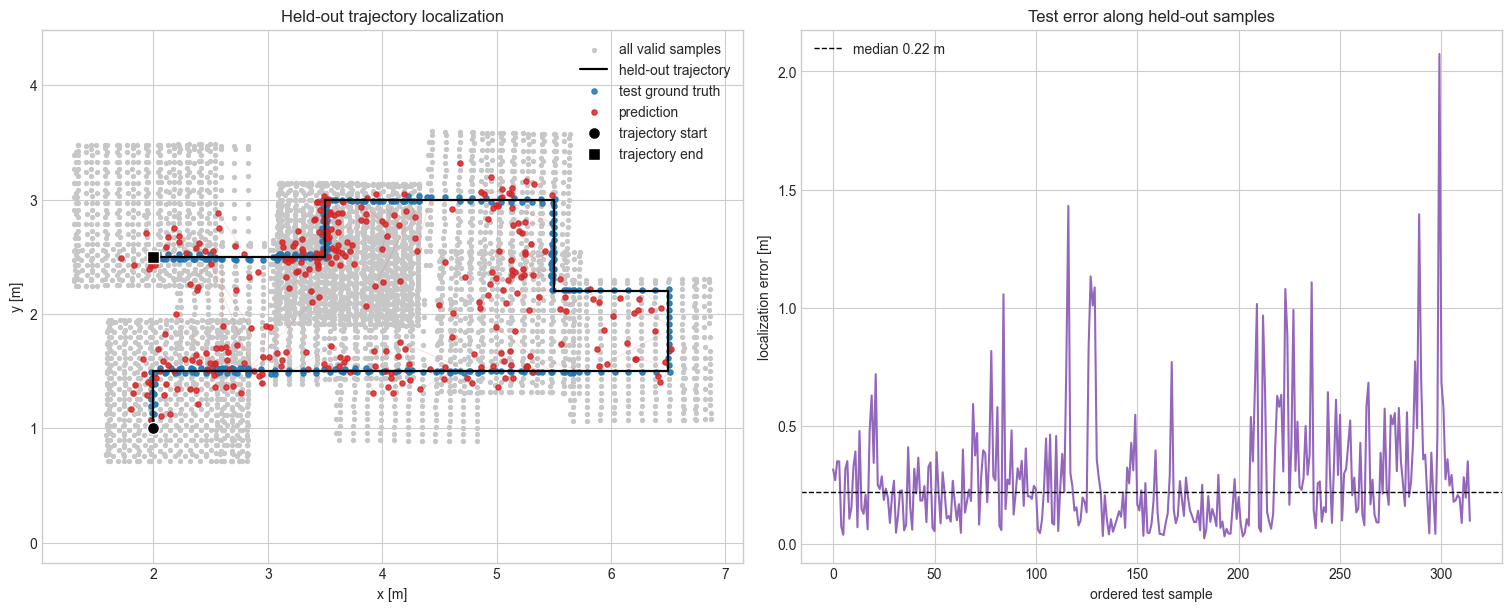

In [ ]:
order = np.lexsort((sample_cycle[test_indices], sample_experiment[test_indices].astype(str)))
ordered_test_indices = test_indices[order]
ordered_true = y_xy[ordered_test_indices]
ordered_pred = test_pred[order]
ordered_error = test_error[order]
ordered_labels = np.asarray([
    f"{experiment}:{cycle}"
    for experiment, cycle in zip(sample_experiment[ordered_test_indices], sample_cycle[ordered_test_indices])
], dtype=object)

trajectory_x = TEST_TRAJECTORY_VERTICES[:, 0]
trajectory_y = TEST_TRAJECTORY_VERTICES[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].scatter(y_xy[:, 0], y_xy[:, 1], s=8, color="0.78", label="all valid samples")
axes[0].plot(trajectory_x, trajectory_y, color="black", linewidth=1.6, label="held-out trajectory")
axes[0].scatter(ordered_true[:, 0], ordered_true[:, 1], color="tab:blue", s=14, alpha=0.85, label="test ground truth")
axes[0].scatter(ordered_pred[:, 0], ordered_pred[:, 1], color="tab:red", s=14, alpha=0.85, label="prediction")
for true_xy, pred_xy in zip(ordered_true[:: max(1, len(ordered_true) // 80)], ordered_pred[:: max(1, len(ordered_pred) // 80)]):
    axes[0].plot([true_xy[0], pred_xy[0]], [true_xy[1], pred_xy[1]], color="tab:red", alpha=0.15, linewidth=0.7)
axes[0].scatter(trajectory_x[0], trajectory_y[0], marker="o", s=75, color="black", edgecolor="white", zorder=5, label="trajectory start")
axes[0].scatter(trajectory_x[-1], trajectory_y[-1], marker="s", s=75, color="black", edgecolor="white", zorder=5, label="trajectory end")
axes[0].set_title("Held-out trajectory localization")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].axis("equal")
axes[0].legend(loc="best")

axes[1].plot(np.arange(len(ordered_error)), ordered_error, color="tab:purple", linewidth=1.5)
axes[1].axhline(test_metrics["median_m"], color="black", linestyle="--", linewidth=1.0, label=f"median {test_metrics['median_m']:.2f} m")
axes[1].axhline(test_metrics["mae_m"], color="red", linestyle="--", linewidth=1.0, label=f"MAE {test_metrics['mae_m']:.2f} m")
axes[1].set_title("Test error along held-out samples")
axes[1].set_xlabel("ordered test sample")
axes[1].set_ylabel("localization error [m]")
axes[1].legend(loc="best")

plt.show()

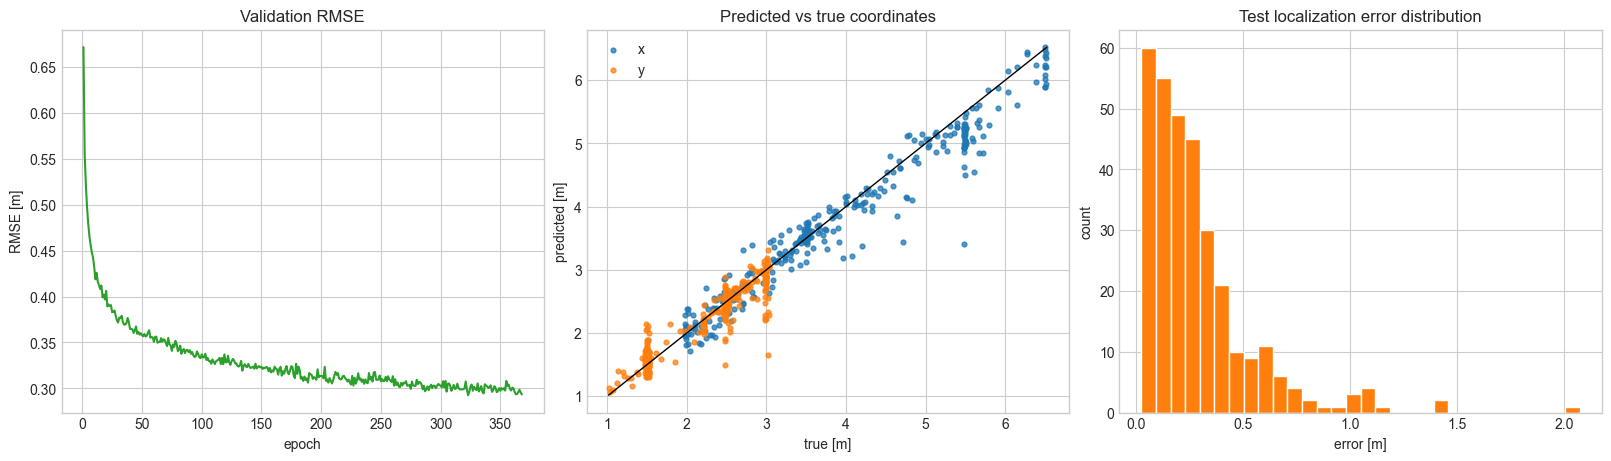

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

axes[0].plot(history[:, 0], history[:, 2], color="tab:green")
axes[0].set_title("Validation RMSE")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("RMSE [m]")

axes[1].scatter(ordered_true[:, 0], ordered_pred[:, 0], s=12, alpha=0.75, label="x")
axes[1].scatter(ordered_true[:, 1], ordered_pred[:, 1], s=12, alpha=0.75, label="y")
coord_min = float(min(ordered_true.min(), ordered_pred.min()))
coord_max = float(max(ordered_true.max(), ordered_pred.max()))
axes[1].plot([coord_min, coord_max], [coord_min, coord_max], color="black", linewidth=1)
axes[1].set_title("Predicted vs true coordinates")
axes[1].set_xlabel("true [m]")
axes[1].set_ylabel("predicted [m]")
axes[1].legend(loc="best")

axes[2].hist(test_error, bins=30, color="tab:orange", edgecolor="white")
axes[2].set_title("Test localization error distribution")
axes[2].set_xlabel("error [m]")
axes[2].set_ylabel("count")

plt.show()